In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
import joblib
from sklearn.pipeline import Pipeline

In [2]:
bodyfat = pd.read_csv(r"C:\Users\HP\James T\ML\body-fat-prediction\data\bodyfat.csv")

In [3]:
bodyfat.head()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
0,1.0708,12.3,23,154.25,67.75,36.2,93.1,85.2,94.5,59.0,37.3,21.9,32.0,27.4,17.1
1,1.0853,6.1,22,173.25,72.25,38.5,93.6,83.0,98.7,58.7,37.3,23.4,30.5,28.9,18.2
2,1.0414,25.3,22,154.00,66.25,34.0,95.8,87.9,99.2,59.6,38.9,24.0,28.8,25.2,16.6
3,1.0751,10.4,26,184.75,72.25,37.4,101.8,86.4,101.2,60.1,37.3,22.8,32.4,29.4,18.2
4,1.0340,28.7,24,184.25,71.25,34.4,97.3,100.0,101.9,63.2,42.2,24.0,32.2,27.7,17.7


In [4]:
bodyfat.info()

<class 'pandas.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   BodyFat  252 non-null    float64
 2   Age      252 non-null    int64  
 3   Weight   252 non-null    float64
 4   Height   252 non-null    float64
 5   Neck     252 non-null    float64
 6   Chest    252 non-null    float64
 7   Abdomen  252 non-null    float64
 8   Hip      252 non-null    float64
 9   Thigh    252 non-null    float64
 10  Knee     252 non-null    float64
 11  Ankle    252 non-null    float64
 12  Biceps   252 non-null    float64
 13  Forearm  252 non-null    float64
 14  Wrist    252 non-null    float64
dtypes: float64(14), int64(1)
memory usage: 29.7 KB


In [5]:
bodyfat.describe()

,Density,BodyFat,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,1.055574,19.150794,44.884921,178.924405,70.148810,37.992063,100.824206,92.555952,99.904762,59.405952,38.590476,23.102381,32.273413,28.663889,18.229762
std,0.019031,8.368740,12.602040,29.389160,3.662856,2.430913,8.430476,10.783077,7.164058,5.249952,2.411805,1.694893,3.021274,2.020691,0.933585
min,0.995000,0.000000,22.000000,118.500000,29.500000,31.100000,79.300000,69.400000,85.000000,47.200000,33.000000,19.100000,24.800000,21.000000,15.800000
25%,1.041400,12.475000,35.750000,159.000000,68.250000,36.400000,94.350000,84.575000,95.500000,56.000000,36.975000,22.000000,30.200000,27.300000,17.600000
50%,1.054900,19.200000,43.000000,176.500000,70.000000,38.000000,99.650000,90.950000,99.300000,59.000000,38.500000,22.800000,32.050000,28.700000,18.300000
75%,1.070400,25.300000,54.000000,197.000000,72.250000,39.425000,105.375000,99.325000,103.525000,62.350000,39.925000,24.000000,34.325000,30.000000,18.800000
max,1.108900,47.500000,81.000000,363.150000,77.750000,51.200000,136.200000,148.100000,147.700000,87.300000,49.100000,33.900000,45.000000,34.900000,21.400000


In [6]:
bodyfat.isna().sum()

Density    0
BodyFat    0
Age        0
Weight     0
Height     0
Neck       0
Chest      0
Abdomen    0
Hip        0
Thigh      0
Knee       0
Ankle      0
Biceps     0
Forearm    0
Wrist      0
dtype: int64

In [7]:
bodyfat = bodyfat.drop_duplicates()

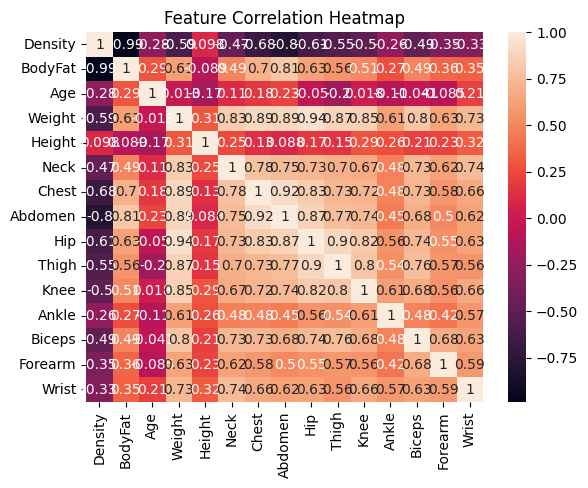

In [8]:
sns.heatmap(bodyfat.corr(), annot = True)
plt.title("Feature Correlation Heatmap")
plt.show()

In [9]:
strong_corr = bodyfat.corr()["BodyFat"].abs().sort_values(ascending = False)

strong_corr

BodyFat    1.000000
Density    0.987782
Abdomen    0.813432
Chest      0.702620
Hip        0.625201
Weight     0.612414
Thigh      0.559608
Knee       0.508665
Biceps     0.493271
Neck       0.490592
Forearm    0.361387
Wrist      0.346575
Age        0.291458
Ankle      0.265970
Height     0.089495
Name: BodyFat, dtype: float64

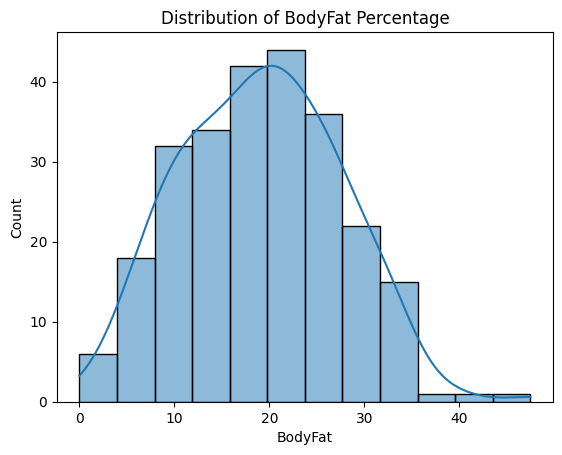

In [10]:
sns.histplot(bodyfat["BodyFat"], kde = True)
plt.title("Distribution of BodyFat Percentage")
plt.show()

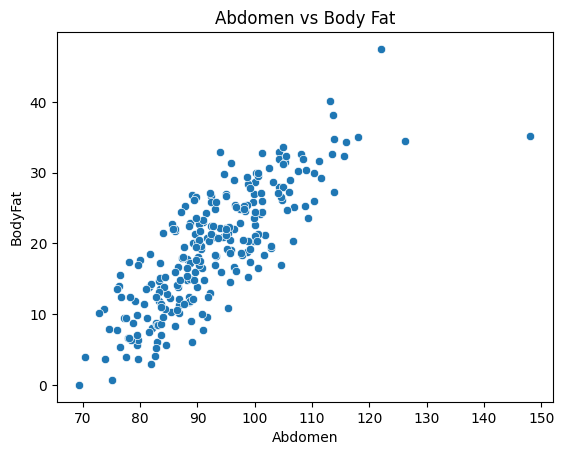

In [11]:
sns.scatterplot(x = 'Abdomen', y = 'BodyFat', data = bodyfat)
plt.title("Abdomen vs Body Fat")
plt.show()

In [12]:
q1 = bodyfat.quantile(0.25)
q3 = bodyfat.quantile(0.75)
iqr = q3 - q1 

bodyfat = bodyfat[~((bodyfat < (q1 - 1.5 * iqr)) | (bodyfat > (q3+ 1.5 * iqr))).any(axis = 1)]

In [13]:
x = bodyfat.drop(columns = ["BodyFat", "Density"])
y = bodyfat['BodyFat']

In [14]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.3, random_state = 42
)

In [15]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [16]:
joblib.dump(scaler, r"C:\Users\HP\James T\ML\body-fat-prediction\models\scaler.pkl")

['C:\\Users\\HP\\James T\\ML\\body-fat-prediction\\models\\scaler.pkl']

In [17]:
models = {
    'LinearRegression' : LinearRegression(),
    'Ridge' : Ridge(),
    'Lasso' : Lasso(),
    'RandomForest' : RandomForestRegressor( random_state = 42)
}

In [18]:
params = {
    'Ridge' : {'alpha' : [0.1, 1.0, 10.0, 100.0]}, 
    'Lasso' : {'alpha' : [0.001, 0.01, 0.1, 1]},
    'RandomForest' : {
        "n_estimators" : [100, 200, 300],
        "max_depth" : [None, 10, 20, 30],
        "min_samples_split" : [2, 5, 10],
        "min_samples_leaf" : [1, 2, 4],
        "max_features" : ["sqrt", "log2", None]
    }
}

In [19]:
best_models = {}
for name, model in models.items():
    if name in params:
        grid = GridSearchCV(model, params[name], cv = 5, scoring = 'r2', n_jobs = -1)
        grid.fit(x_train_scaled, y_train)
        best_models[name] = grid.best_estimator_
        print(f"Best parameters for {name} : {grid.best_params_}")
    else : 
        model.fit(x_train_scaled, y_train)
        best_models[name] = model

Best parameters for Ridge : {'alpha': 1.0}
Best parameters for Lasso : {'alpha': 0.1}
Best parameters for RandomForest : {'max_depth': None, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}


In [20]:
for name, model in best_models.items():
    y_pred = model.predict(x_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print("Model :", name)
    print(f"MAE : {mae:.3f}, RMSE : {rmse:.3f}, R2 Score : {r2:.3f}\n")

Model : LinearRegression
MAE : 3.681, RMSE : 4.385, R2 Score : 0.653

Model : Ridge
MAE : 3.689, RMSE : 4.386, R2 Score : 0.653

Model : Lasso
MAE : 3.620, RMSE : 4.340, R2 Score : 0.660

Model : RandomForest
MAE : 3.594, RMSE : 4.467, R2 Score : 0.640



In [21]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [22]:
print("MAE :", mae)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 3.5938255970727706
RMSE : 4.466619661541004
R2 Score : 0.6402514235618728


In [23]:
print(x.columns)
print(x.shape)

Index(['Age', 'Weight', 'Height', 'Neck', 'Chest', 'Abdomen', 'Hip', 'Thigh',
       'Knee', 'Ankle', 'Biceps', 'Forearm', 'Wrist'],
      dtype='str')
(234, 13)


In [24]:
feature_names = x.columns
joblib.dump(feature_names, "features.pkl")

['features.pkl']

In [25]:
best_model = best_models["LinearRegression"]
joblib.dump(best_model, r"C:\Users\HP\James T\ML\body-fat-prediction\models\linear_regression_model.pkl")

['C:\\Users\\HP\\James T\\ML\\body-fat-prediction\\models\\linear_regression_model.pkl']

In [26]:
# =========================
# SAVE FEATURE IMPORTANCE (LINEAR MODEL)
# =========================

# LinearRegression always has coef_
if hasattr(best_model, "coef_"):

    coefficients = pd.DataFrame({
        "Feature": x.columns,
        "Coefficient": best_model.coef_
    })

    # absolute importance
    coefficients["Abs"] = coefficients["Coefficient"].abs()

    # sort by importance
    coefficients = coefficients.sort_values("Abs", ascending=False)

    # save for Streamlit dashboard
    coefficients.to_csv(
        r"C:\Users\HP\James T\ML\body-fat-prediction\models\coefficients.csv",
        index=False
    )

    print("\n✅ Feature importance saved successfully.")


✅ Feature importance saved successfully.
